# 1 · Replicating the Fama-French Three-Factor Model

Fama and French (1993) argued that the CAPM's single market factor is an incomplete description of average returns. Two extra factors — **size** (SMB, small minus big) and **value** (HML, high minus low book-to-market) — capture a large slice of the cross-section the CAPM misses.

The model regresses a portfolio's excess return on the three factors:

$$R_i - R_f = \alpha_i + \beta_i\,(R_m - R_f) + s_i\,\text{SMB} + h_i\,\text{HML} + \varepsilon_i$$

Here we reproduce the original-sample result on Ken French's canonical test assets: the **25 portfolios** double-sorted on size and book-to-market. A faithful replication should show (a) a large jump in $R^2$ over the CAPM and (b) loadings that line up monotonically with each portfolio's size and value tilt.

> **Data note.** The bundled cache is real Ken French data built from his daily research files (see `data/README.md`). Calling `dl.load_all(download=True)` refreshes everything to the present from the official monthly files.

In [1]:
import sys; sys.path.insert(0, "../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import data_loader as dl, analysis as an

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e9ebef"})
NAVY, TEAL, RUST, GREY = "#1f2a44", "#2a9d8f", "#c1463c", "#8a8f99"

# download=False uses the bundled cache; set True to refresh from Ken French.
factors, ports = dl.load_all(download=False)
VINTAGE = f"{factors.index.max():%b %Y}"
print(f"{len(factors)} months  {factors.index.min():%Y-%m} .. {factors.index.max():%Y-%m}")


682 months  1963-07 .. 2020-04


## Factor premia, 1963–present
First, the raw building blocks. Over the full sample all three factors earned a positive average premium, with the market the largest.

In [2]:
summary = pd.DataFrame({
    "mean %/mo": factors.mean() * 100,
    "ann %":     ((1 + factors.mean()) ** 12 - 1) * 100,
    "ann vol %": factors.std() * np.sqrt(12) * 100,
})
summary.loc[["Mkt-RF", "SMB", "HML", "RF"]].round(2)

,mean %/mo,ann %,ann vol %
Mkt-RF,0.530,6.500,15.410
SMB,0.150,1.870,10.470
HML,0.290,3.540,9.930
RF,0.380,4.610,0.910


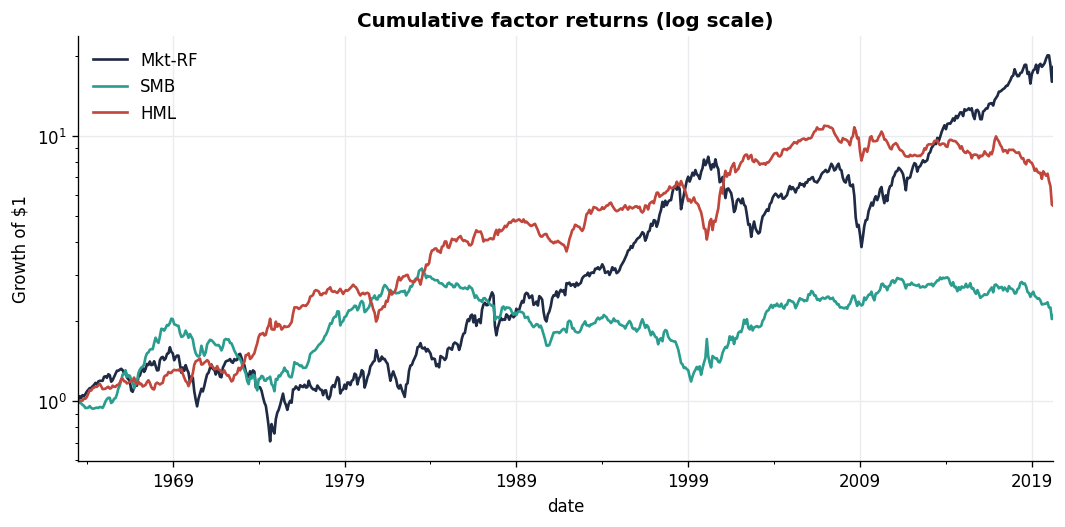

In [3]:
cum = (1 + factors[["Mkt-RF", "SMB", "HML"]]).cumprod()
ax = cum.plot(figsize=(9, 4.5), color=[NAVY, TEAL, RUST], lw=1.6, logy=True)
ax.set_title("Cumulative factor returns (log scale)", weight="bold")
ax.set_ylabel("Growth of $1"); ax.legend(frameon=False); plt.tight_layout()

## CAPM vs FF3 on a single portfolio
Take the **small-value** corner (`SMALL HiBM`) — historically the highest-returning cell. The CAPM leaves a big positive alpha; adding SMB and HML absorbs it and lifts $R^2$ sharply.

In [4]:
orig_f = factors.loc["1963-07":"1991-12"]
orig_p = ports.loc["1963-07":"1991-12"]
sv = orig_p["SMALL HiBM"]

capm = an.run_capm(sv, orig_f)
ff3  = an.run_ff3(sv, orig_f)
pd.DataFrame({
    "CAPM": {"alpha %/mo": capm.params["const"]*100, "alpha t": capm.tvalues["const"],
             "R2": capm.rsquared},
    "FF3":  {"alpha %/mo": ff3.params["const"]*100,  "alpha t": ff3.tvalues["const"],
             "R2": ff3.rsquared},
}).round(3)

,CAPM,FF3
alpha %/mo,0.533,0.116
alpha t,2.597,1.641
R2,0.642,0.960


In [5]:
print(ff3.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012      0.001      1.641      0.102      -0.000       0.003
Mkt-RF         0.9473      0.018     54.112      0.000       0.913       0.982
SMB            1.1528      0.025     46.056      0.000       1.104       1.202
HML            0.5502      0.030     18.409      0.000       0.491       0.609


The CAPM alpha is large and significant — the CAPM cannot explain why small-value did so well. Under FF3 the alpha shrinks toward zero while the SMB and HML loadings are large and highly significant: the return was *compensation for size and value exposure*, not unexplained skill.

## The whole cross-section: 25 portfolios
Now every portfolio at once. The table reports FF3 loadings with the HML t-stat, plus the $R^2$ under CAPM and FF3.

In [6]:
tbl = an.loadings_table(orig_p, orig_f)
tbl[["beta_MKT", "s_SMB", "h_HML", "t_HML", "R2_CAPM", "R2_FF3", "dR2"]].round(3)

,beta_MKT,s_SMB,h_HML,t_HML,R2_CAPM,R2_FF3,dR2
portfolio,,,,,,,
SMALL LoBM,1.019,1.363,-0.390,-8.754,0.702,0.941,0.239
ME1 BM2,0.953,1.248,-0.005,-0.138,0.701,0.958,0.257
ME1 BM3,0.932,1.117,0.196,6.832,0.707,0.962,0.255
ME1 BM4,0.889,1.063,0.310,11.711,0.690,0.964,0.274
SMALL HiBM,0.947,1.153,0.550,18.409,0.642,0.960,0.317
ME2 BM1,1.089,0.971,-0.552,-15.613,0.805,0.958,0.153
ME2 BM2,1.008,0.913,-0.037,-1.247,0.800,0.961,0.160
ME2 BM3,0.955,0.813,0.178,6.287,0.790,0.956,0.166
ME2 BM4,0.964,0.673,0.431,15.668,0.783,0.952,0.169


In [7]:
print(f"mean R^2  CAPM = {tbl['R2_CAPM'].mean():.3f}")
print(f"mean R^2  FF3  = {tbl['R2_FF3'].mean():.3f}")
print(f"mean gain     = +{tbl['dR2'].mean():.3f}")
print(f"mean |alpha|  = {tbl['alpha_%mo'].abs().mean():.3f} %/mo")

mean R^2  CAPM = 0.792
mean R^2  FF3  = 0.932
mean gain     = +0.139
mean |alpha|  = 0.104 %/mo


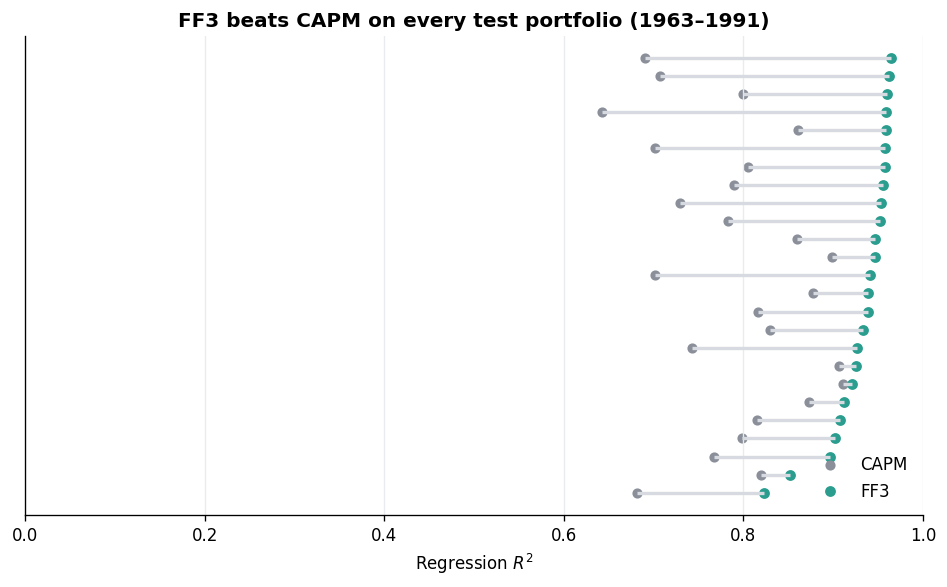

In [8]:
# Dumbbell: CAPM vs FF3 R-squared for all 25 portfolios
order = tbl.sort_values("R2_FF3").index
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(8, 5))
ax.hlines(y, tbl.loc[order,"R2_CAPM"], tbl.loc[order,"R2_FF3"], color="#d7dae0", lw=2)
ax.scatter(tbl.loc[order,"R2_CAPM"], y, color=GREY, s=26, label="CAPM")
ax.scatter(tbl.loc[order,"R2_FF3"],  y, color=TEAL, s=30, label="FF3")
ax.set_yticks([]); ax.set_xlim(0, 1); ax.set_xlabel("Regression $R^2$")
ax.set_title("FF3 beats CAPM on every test portfolio (1963–1991)", weight="bold")
ax.legend(frameon=False, loc="lower right"); plt.tight_layout()

## Where do the loadings come from?
Reshaping the 25 HML loadings into the original 5×5 grid shows the value factor doing exactly its job: loadings climb monotonically from growth (left) to value (right).

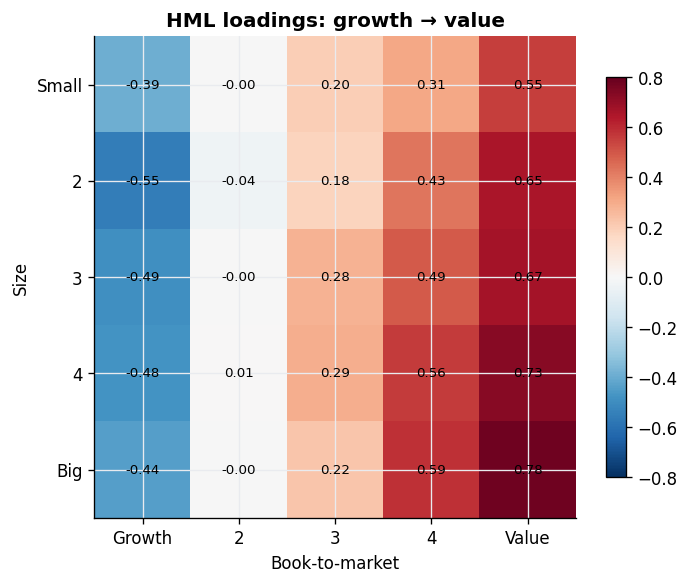

In [9]:
grid = tbl["h_HML"].values.reshape(5, 5)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(grid, cmap="RdBu_r", vmin=-0.8, vmax=0.8)
ax.set_xticks(range(5)); ax.set_xticklabels(["Growth","2","3","4","Value"])
ax.set_yticks(range(5)); ax.set_yticklabels(["Small","2","3","4","Big"])
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{grid[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_xlabel("Book-to-market"); ax.set_ylabel("Size")
ax.set_title("HML loadings: growth → value", weight="bold")
fig.colorbar(im, shrink=0.8); plt.tight_layout()

### Takeaway
The replication lands where the 1993 paper did: across the 25 portfolios the average $R^2$ rises from roughly **0.79 under the CAPM to 0.93 under FF3**, alphas collapse toward zero, and the SMB/HML loadings map cleanly onto each portfolio's size and value tilt. The two extra factors are doing real work. **Notebook 2** asks the harder question: has the value factor kept working?